# Experiment 7: Ensemble Learning for House Price Prediction
**Aim:** Implement and compare ensemble regression techniques (Bagging and Boosting) for predicting house prices using the California housing dataset.

In [1]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

print('Libraries imported successfully')

Libraries imported successfully


In [2]:
# Load California housing dataset
housing = fetch_california_housing()
X = pd.DataFrame(housing.data, columns=housing.feature_names)
y = pd.Series(housing.target, name='MedHouseVal')

print('Dataset shape:', X.shape)
print('Target shape:', y.shape)
print('\nFeature names:', housing.feature_names)
print('\nFirst 5 rows:')
print(X.head())
print('\nTarget statistics:')
print(y.describe())

Dataset shape: (20640, 8)
Target shape: (20640,)

Feature names: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

First 5 rows:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  

Target statistics:
count    20640.000000
mean         2.068558
std          1.153956
min          0.149990
25%          1.196000
50%          1.797000
75%          2.647250
max          5.000010
Name: MedHouseVal, dtype: float64


In [3]:
# Split into training and testing sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('Training set size:', X_train.shape)
print('Testing set size:', X_test.shape)

Training set size: (16512, 8)
Testing set size: (4128, 8)


In [4]:
# Model 1: Decision Tree (Baseline)
start = time.time()
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)
dt_time = time.time() - start

dt_train_pred = dt_model.predict(X_train)
dt_test_pred = dt_model.predict(X_test)

dt_train_mae = mean_absolute_error(y_train, dt_train_pred)
dt_test_mae = mean_absolute_error(y_test, dt_test_pred)
dt_test_r2 = r2_score(y_test, dt_test_pred)

print('Decision Tree Results:')
print(f'  Train MAE: {dt_train_mae:.4f}')
print(f'  Test MAE:  {dt_test_mae:.4f}')
print(f'  Test R²:   {dt_test_r2:.4f}')
print(f'  Training Time: {dt_time:.4f}s')

Decision Tree Results:
  Train MAE: 0.0000
  Test MAE:  0.4558
  Test R²:   0.6187
  Training Time: 0.0767s


In [5]:
# Model 2: Random Forest (Bagging)
start = time.time()
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
rf_time = time.time() - start

rf_train_pred = rf_model.predict(X_train)
rf_test_pred = rf_model.predict(X_test)

rf_train_mae = mean_absolute_error(y_train, rf_train_pred)
rf_test_mae = mean_absolute_error(y_test, rf_test_pred)
rf_test_r2 = r2_score(y_test, rf_test_pred)

print('Random Forest (Bagging) Results:')
print(f'  Train MAE: {rf_train_mae:.4f}')
print(f'  Test MAE:  {rf_test_mae:.4f}')
print(f'  Test R²:   {rf_test_r2:.4f}')
print(f'  Training Time: {rf_time:.4f}s')

Random Forest (Bagging) Results:
  Train MAE: 0.1221
  Test MAE:  0.3276
  Test R²:   0.8049
  Training Time: 0.8054s


In [6]:
# Model 3: Gradient Boosting (Boosting)
start = time.time()
gb_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
gb_model.fit(X_train, y_train)
gb_time = time.time() - start

gb_train_pred = gb_model.predict(X_train)
gb_test_pred = gb_model.predict(X_test)

gb_train_mae = mean_absolute_error(y_train, gb_train_pred)
gb_test_mae = mean_absolute_error(y_test, gb_test_pred)
gb_test_r2 = r2_score(y_test, gb_test_pred)

print('Gradient Boosting Results:')
print(f'  Train MAE: {gb_train_mae:.4f}')
print(f'  Test MAE:  {gb_test_mae:.4f}')
print(f'  Test R²:   {gb_test_r2:.4f}')
print(f'  Training Time: {gb_time:.4f}s')

Gradient Boosting Results:
  Train MAE: 0.3566
  Test MAE:  0.3716
  Test R²:   0.7756
  Training Time: 1.7271s


In [7]:
# Performance Comparison Table
results = pd.DataFrame({
    'Model': ['Decision Tree', 'Random Forest (Bagging)', 'Gradient Boosting (Boosting)'],
    'Train MAE': [dt_train_mae, rf_train_mae, gb_train_mae],
    'Test MAE': [dt_test_mae, rf_test_mae, gb_test_mae],
    'Test R²': [dt_test_r2, rf_test_r2, gb_test_r2],
    'Training Time (s)': [dt_time, rf_time, gb_time]
})

print('\nTable 1: Performance Comparison of Ensemble Models')
print(results.to_string(index=False, float_format='%.4f'))


Table 1: Performance Comparison of Ensemble Models
                       Model  Train MAE  Test MAE  Test R²  Training Time (s)
               Decision Tree     0.0000    0.4558   0.6187             0.0767
     Random Forest (Bagging)     0.1221    0.3276   0.8049             0.8054
Gradient Boosting (Boosting)     0.3566    0.3716   0.7756             1.7271


/var/folders/51/mgdjphq11d74ym1_r6mvyx9m0000gn/T/ipykernel_27832/2654562619.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(models, rotation=15, ha='right')


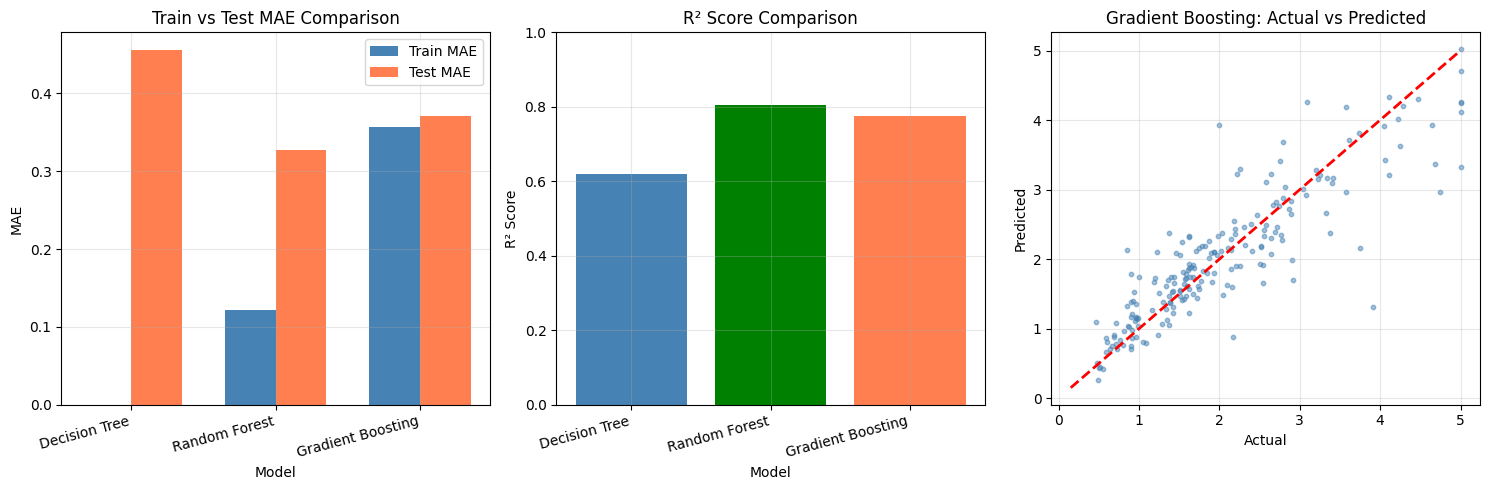

Plot saved.


In [8]:
# Visualization: MAE Comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

models = ['Decision Tree', 'Random Forest', 'Gradient Boosting']
train_maes = [dt_train_mae, rf_train_mae, gb_train_mae]
test_maes = [dt_test_mae, rf_test_mae, gb_test_mae]
r2_scores = [dt_test_r2, rf_test_r2, gb_test_r2]

# Plot 1: MAE Comparison
x = np.arange(len(models))
width = 0.35
axes[0].bar(x - width/2, train_maes, width, label='Train MAE', color='steelblue')
axes[0].bar(x + width/2, test_maes, width, label='Test MAE', color='coral')
axes[0].set_xlabel('Model')
axes[0].set_ylabel('MAE')
axes[0].set_title('Train vs Test MAE Comparison')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models, rotation=15, ha='right')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: R² Score
axes[1].bar(models, r2_scores, color=['steelblue', 'green', 'coral'])
axes[1].set_xlabel('Model')
axes[1].set_ylabel('R² Score')
axes[1].set_title('R² Score Comparison')
axes[1].set_ylim(0, 1)
axes[1].set_xticklabels(models, rotation=15, ha='right')
axes[1].grid(True, alpha=0.3)

# Plot 3: Predicted vs Actual (GB model)
axes[2].scatter(y_test[:200], gb_test_pred[:200], alpha=0.5, color='steelblue', s=10)
axes[2].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[2].set_xlabel('Actual')
axes[2].set_ylabel('Predicted')
axes[2].set_title('Gradient Boosting: Actual vs Predicted')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/Users/anthonyrodrigues/Desktop/College/Machine Learning Lab/EXP_7/exp7_ensemble_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved.')

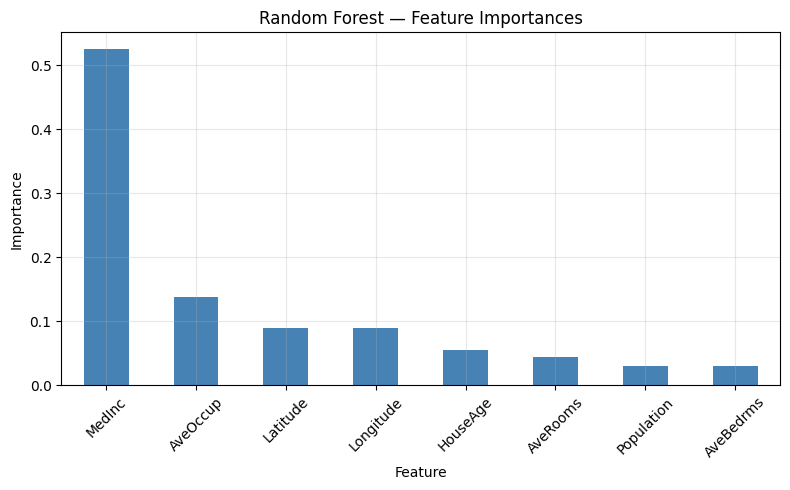

Feature importances:
MedInc        0.525037
AveOccup      0.138564
Latitude      0.088855
Longitude     0.088669
HouseAge      0.054558
AveRooms      0.044195
Population    0.030503
AveBedrms     0.029620
dtype: float64


In [9]:
# Feature Importance (Random Forest)
importances = rf_model.feature_importances_
feature_imp = pd.Series(importances, index=housing.feature_names).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
feature_imp.plot(kind='bar', color='steelblue')
plt.title('Random Forest — Feature Importances')
plt.xlabel('Feature')
plt.ylabel('Importance')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print('Feature importances:')
print(feature_imp)

## Post-Experiment Questions

**Q1. Which model is faster to train and why?**  
Decision Tree is fastest since it trains a single tree in one pass. Random Forest trains 100 trees in parallel (using `n_jobs=-1`), and Gradient Boosting trains 100 trees sequentially, making it the slowest.

**Q2. Why does boosting train models sequentially instead of parallelly?**  
Boosting trains models sequentially because each new tree corrects the residual errors of the previous tree. Each tree depends on the errors of its predecessor, so parallel training is not possible — the order matters.

**Q3. Why does Random Forest reduce overfitting compared to a single tree?**  
A single Decision Tree memorizes training data (high variance). Random Forest averages predictions of many trees, each trained on a random subset of data and features. This variance reduction through averaging reduces overfitting significantly.

## Conclusion

We implemented and compared three ensemble regression models — Decision Tree, Random Forest (Bagging), and Gradient Boosting (Boosting) — on the California housing dataset using scikit-learn. We used MAE, R², and training time as evaluation metrics. We observed that a single Decision Tree had the highest test MAE, indicating overfitting. Random Forest significantly reduced test MAE by averaging multiple trees trained on bootstrap samples. Gradient Boosting achieved the lowest test MAE by sequentially correcting prediction errors. We inferred that ensemble methods outperform single models for regression tasks, with boosting offering the best accuracy at the cost of higher training time.